In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import sys

sys.path.append('/home/yuliya/repos/cosybio/FedProt/evaluation_utils/')
from evaluation import evaluation_func as fp_eval


from collections import OrderedDict

In [2]:
color_dict = OrderedDict()

color_dict["Methods"] = OrderedDict({
    "FedProt":"black",
    "Fisher":"#D44400",
    "Stouffer":"#E69F00",
    "REM":"#2E5EAA",
    "RankProd":"#009E73"
})

In [3]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/"

# Plot boxplot

In [4]:
# Function to load data based on mode
def load_data(mode):
    rmse_pv_df = pd.read_csv(f"{root_dir}{mode}/aggreagated/RMSE.csv", index_col=0).T
    nrmse_pv_df = pd.read_csv(f"{root_dir}{mode}/aggreagated/NRMSE.csv", index_col=0).T
    r_pv_df = pd.read_csv(f"{root_dir}{mode}/aggreagated/r.csv", index_col=0).T
    rho_pv_df = pd.read_csv(f"{root_dir}{mode}/aggreagated/rho.csv", index_col=0).T
    return rmse_pv_df, nrmse_pv_df, r_pv_df, rho_pv_df

# Plot correlations

In [5]:
def log_transform_df(df):
    df = df.replace(0,1e-300)
    df["pv_DEqMS"] = -np.log10(df["pv_DEqMS"])
    for m in ["FedProt", "Fisher","Stouffer","REM","RankProd"]:
        df["pv_"+m] = -np.log10(df["pv_"+m])
    return df

In [6]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/"

dfs = {}

fedprot_name="DPE.tsv"
deqms_name="res.tsv"
fisher_name="MA_CM.tsv"
rem_name="MA_REM.tsv"
stouffer_name="MA_Stouffer.tsv"
rankprod_name="MA_RankProd.tsv"

# Define configurations for each dataset
configs = [
    {
        "key": "balanced 1x",
        "prefix": "/4_",
        "subdir": "balanced_1x/results",
    },
    {
        "key": "balanced 10x",
        "prefix": "/4_",
        "subdir": "balanced_10x/results",
    },
    {
        "key": "balanced 100x",
        "prefix": "/4_",
        "subdir": "balanced_100x/results",
    },
    {
        "key": "imbalanced 1x",
        "prefix": "/4_",
        "subdir": "strong_imbalanced_1x/results",
    },
    {
        "key": "imbalanced 10x",
        "prefix": "/4_",
        "subdir": "strong_imbalanced_10x/results",
    },
    {
        "key": "imbalanced 100x",
        "prefix": "/4_",
        "subdir": "strong_imbalanced_100x/results",
    }
]

# Iterate through each configuration and process the data
for config in configs:
    workdir = f"{root_dir}{config['subdir']}"
    prefix = config["prefix"]
    
    df = fp_eval.read_results(
        workdir,
        fedprot_name=f"{prefix}{fedprot_name}",
        deqms_name=f"{prefix}{deqms_name}",
        fisher_name=f"{prefix}{fisher_name}",
        rem_name=f"{prefix}{rem_name}",
        stouffer_name=f"{prefix}{stouffer_name}",
        rankprod_name=f"{prefix}{rankprod_name}",
        simulated=True
    )
    
    dfs[config["key"]] = df
    print(f"Loaded {config['key']}")
    # print(df.head())


log_dfs = {k: log_transform_df(v) for k,v in dfs.items()}




Results loaded for DEqMS with 6000 proteins.
Head: 
          logFC      CI.L      CI.R   AveExpr         t       P.Value  \
prt4  1.817401  1.196909  2.437894  1.972726  5.857796  2.070580e-07   

      adj.P.Val         B  sca.adj.pval   sca.P.Value  
prt4   0.000867  6.761489      0.000867  2.070580e-07  


Results loaded for FedProt with 6000 proteins.
Head: 
              t   AveExpr         B     logFC      CI.L      CI.R  \
prt1  4.163901  0.890473  1.148222  1.549376  0.803829  2.294923   

      sca.adj.pval  sca.P.Value  
prt1      0.031443      0.00011  
Results loaded for Fisher with 6000 proteins.
Head: 
      Symbol     metap   metafc       idx    ID
prt4   prt4  0.000004  1.82088  9.804286  prt4
Results loaded for REM with 6000 proteins.
Head: 
      Symbol  signcon  randomSummary  randomCi.lb  randomCi.ub       randomP  \
prt4   prt4        3       1.797996     1.152522     2.443471  4.773103e-08   

        het_QE   het_QEp     het_QM       het_QMp  error  rank    ID  
prt4  0.400678  0.818453  29.806819  4.773103e-08  False     1  prt4  
Results loaded for Stouffer with 6000 proteins.
Head: 
          ind.p.4_lab1  ind.p.4_lab2  ind.p.4_lab3      stat      pval  \
ID                                                                      
prt2518      0.000336      0.554759   

Loaded balanced 1x
Loaded balanced 10x
Loaded balanced 100x


Results loaded for FedProt with 6000 proteins.
Head: 
              t   AveExpr         B     logFC      CI.L      CI.R  \
prt1  2.908698 -0.778932 -2.195168  0.793394  0.247113  1.339675   

      sca.adj.pval  sca.P.Value  
prt1      0.336137     0.005177  
Results loaded for Fisher with 6000 proteins.
Head: 
           Symbol     metap    metafc       idx       ID
prt2153  prt2153  0.000006 -0.871651 -4.581578  prt2153
Results loaded for REM with 6000 proteins.
Head: 
         Symbol  signcon  randomSummary  randomCi.lb  randomCi.ub  \
prt184  prt184       -3      -1.596582    -2.220739    -0.972424   

             randomP    het_QE  het_QEp     het_QM       het_QMp  error  rank  \
prt184  5.343522e-07  1.870134  0.39256  25.135671  5.343522e-07  False     2   

            ID  
prt184  prt184  
Results loaded for Stouffer with 6000 proteins.
Head: 
          ind.p.4_lab1  ind.p.4_lab2  ind.p.4_lab3      stat      pval  \
ID                                                          

Loaded imbalanced 1x
Loaded imbalanced 10x
Loaded imbalanced 100x


Plotting correlation using p-vals - log-transformed.


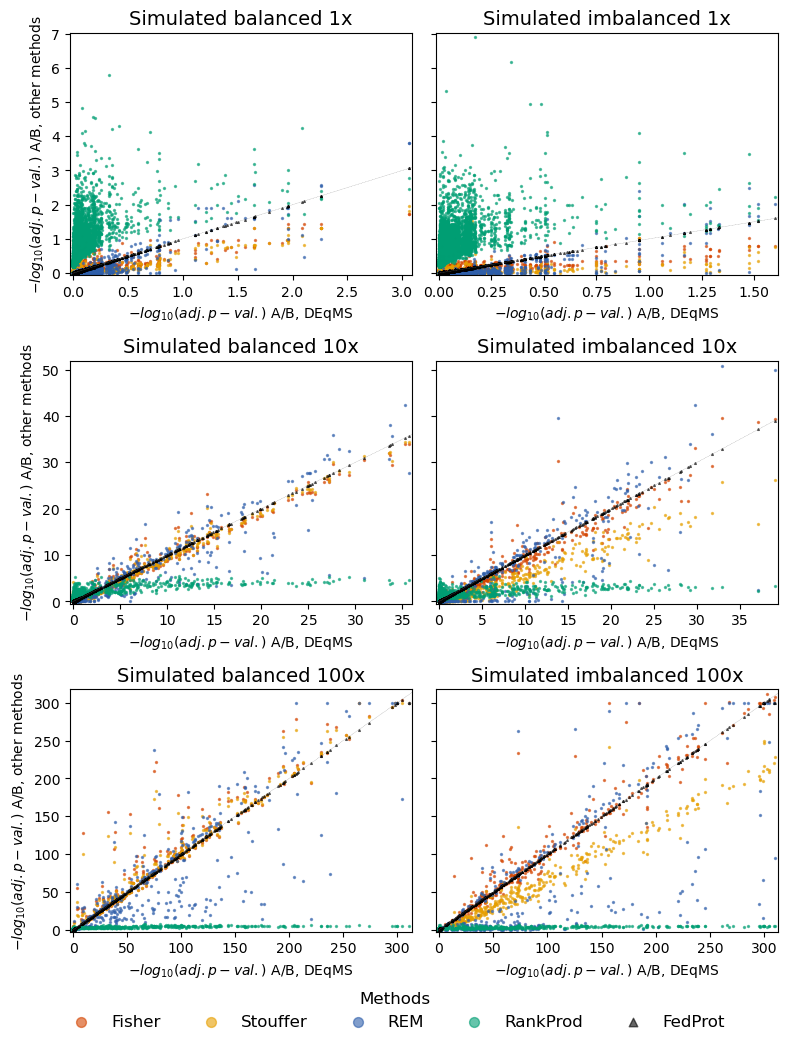

In [7]:
# show results with dpi=600

plot = fp_eval.plt_results(
    log_dfs, 
    methods=["Fisher","Stouffer","REM","RankProd", "FedProt"],
    color_dict=color_dict,
    what="pv_", 
    text="", dotsize=2,
    sharex = False,
    datasets=["balanced 1x", "balanced 10x", "balanced 100x", "imbalanced 1x", "imbalanced 10x", "imbalanced 100x"],
    comparsions = ["A/B", "A/B", "A/B", "A/B", "A/B", "A/B"],
    add_table=False,
    figsize=(8, 10),
    after_comma=2,
    titles = ["Simulated balanced 1x", "Simulated imbalanced 1x",
              "Simulated balanced 10x", "Simulated imbalanced 10x", 
              "Simulated balanced 100x",  "Simulated imbalanced 100x"],
    adjust_structure = [
        (3, 2),
        ("balanced 1x", "imbalanced 1x", 
         "balanced 10x", "imbalanced 10x", 
         "balanced 100x", "imbalanced 100x")
    ]
)


Plotting correlation using logFC values.


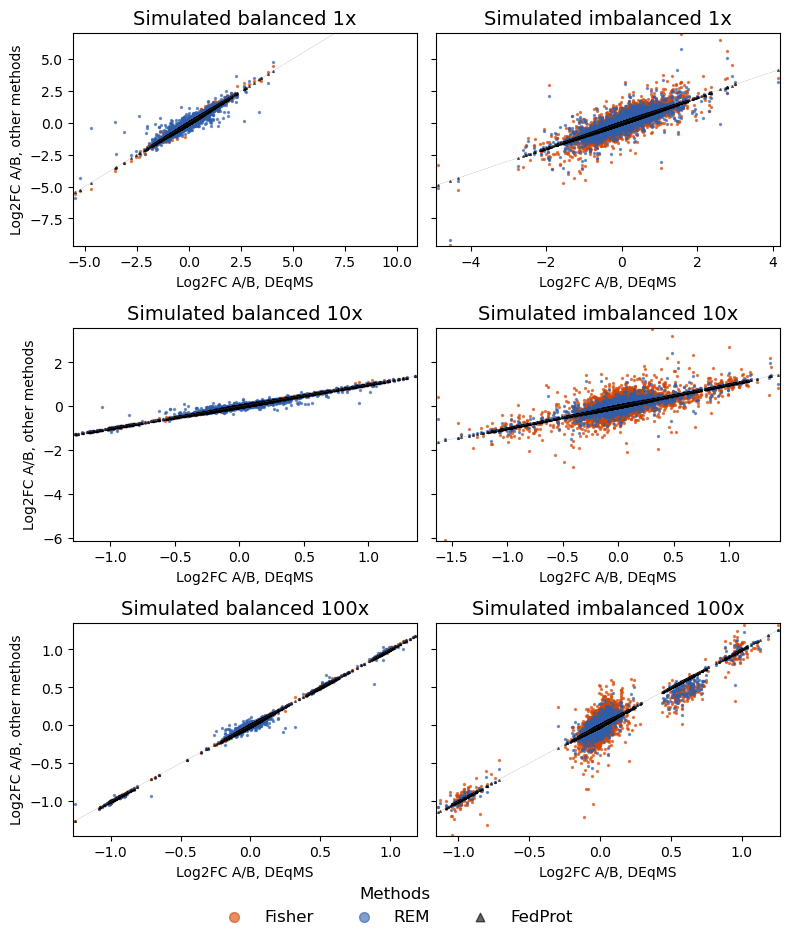

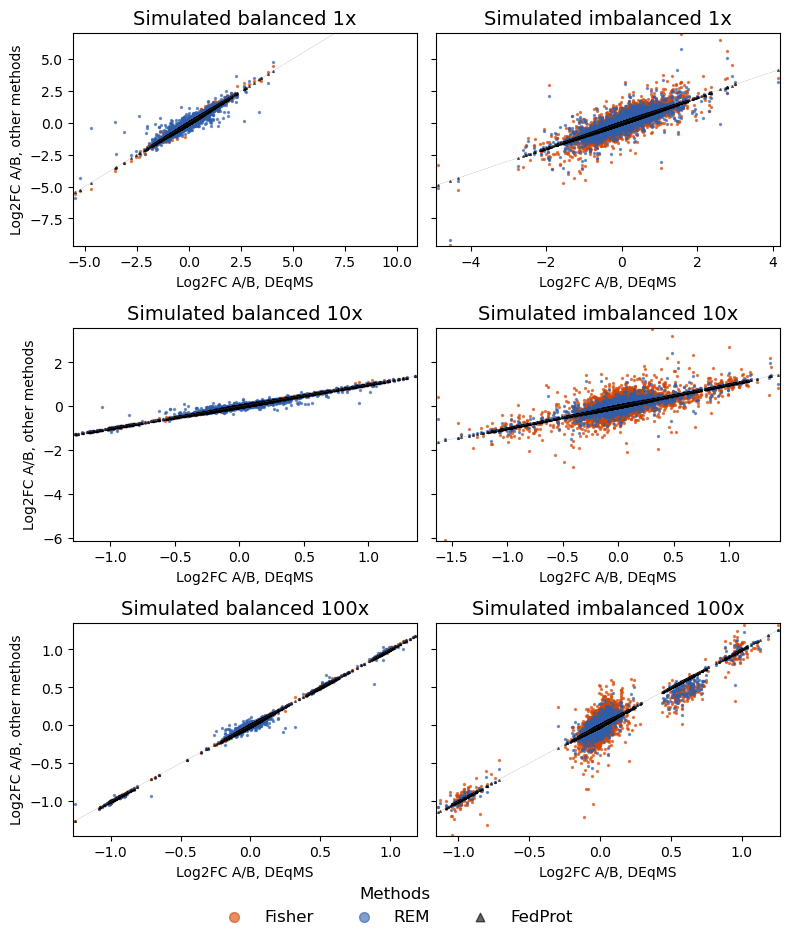

In [8]:
selected_colors = OrderedDict()
selected_colors["Methods"] = OrderedDict({
    "FedProt":"black",
    "Fisher":"#D44400",
    "REM":"#2E5EAA"
})

fp_eval.plt_results(
    log_dfs, 
    methods=["Fisher", "REM", "FedProt"],
    color_dict=selected_colors,
    what="lfc_", 
    text="", dotsize=2,
    datasets=["balanced 1x", "balanced 10x", "balanced 100x", "imbalanced 1x", "imbalanced 10x", "imbalanced 100x"],
    comparsions = ["A/B", "A/B", "A/B", "A/B", "A/B", "A/B"],
    add_table=False,
    figsize=(8, 9),
    # set_lims=[[-2,2], [-2,2], [-2,2]],
    titles = ["Simulated balanced 1x", "Simulated imbalanced 1x", 
              "Simulated balanced 10x", "Simulated imbalanced 10x", 
              "Simulated balanced 100x", "Simulated imbalanced 100x"],

    adjust_structure = [
        (3, 2),
        ("balanced 1x", "imbalanced 1x", 
         "balanced 10x", "imbalanced 10x", 
         "balanced 100x", "imbalanced 100x")
    ]
)

In [9]:
# how many values are above 1.7 or below -1.7 for bacterial dataset
for dataset in log_dfs:
    df = log_dfs[dataset]
    number = 2
    print(f"Dataset: {dataset}")
    for method in ["DEqMS", "FedProt", "Fisher", "Stouffer", "REM", "RankProd"]:
        print(f"\tMethod: {method}")
        print(f"\t\tValues [> {number} or < -{number}]: {len(df[(df['lfc_'+method] > number) | (df['lfc_'+method] < -1 * number)])}")
        # % out of all proteins
        print(f"\t\t% of values : {len(df[(df['lfc_'+method] > number) | (df['lfc_'+method] < -1 * number)])/len(df)*100:.2f}%")

Dataset: balanced 1x
	Method: DEqMS
		Values [> 2 or < -2]: 41
		% of values : 0.68%
	Method: FedProt
		Values [> 2 or < -2]: 41
		% of values : 0.68%
	Method: Fisher
		Values [> 2 or < -2]: 40
		% of values : 0.67%
	Method: Stouffer
		Values [> 2 or < -2]: 40
		% of values : 0.67%
	Method: REM
		Values [> 2 or < -2]: 38
		% of values : 0.63%
	Method: RankProd
		Values [> 2 or < -2]: 40
		% of values : 0.67%
Dataset: balanced 10x
	Method: DEqMS
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: FedProt
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: Fisher
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: Stouffer
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: REM
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: RankProd
		Values [> 2 or < -2]: 0
		% of values : 0.00%
Dataset: balanced 100x
	Method: DEqMS
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: FedProt
		Values [> 2 or < -2]: 0
		% of values : 0.00%
	Method: Fisher
		Values [> 2 

# Jaccard plot

In [10]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/"
jaccard_topN_dfs ={
    "Balanced 1x": pd.read_csv(f"{root_dir}balanced_1x/aggreagated/jaccard_topN.csv", index_col=[1]),
    "Balanced 10x": pd.read_csv(f"{root_dir}balanced_10x/aggreagated/jaccard_topN.csv", index_col=[1]),
    "Balanced 100x": pd.read_csv(f"{root_dir}balanced_100x/aggreagated/jaccard_topN.csv", index_col=[1]),
    "Imbalanced 1x": pd.read_csv(f"{root_dir}strong_imbalanced_1x/aggreagated/jaccard_topN.csv", index_col=[1]),
    "Imbalanced 10x": pd.read_csv(f"{root_dir}strong_imbalanced_10x/aggreagated/jaccard_topN.csv", index_col=[1]),
    "Imbalanced 100x": pd.read_csv(f"{root_dir}strong_imbalanced_100x/aggreagated/jaccard_topN.csv", index_col=[1])
}

# remove Unnamed: 0 column
for k, df in jaccard_topN_dfs.items():
    df.drop(df.columns[0], axis=1, inplace=True)


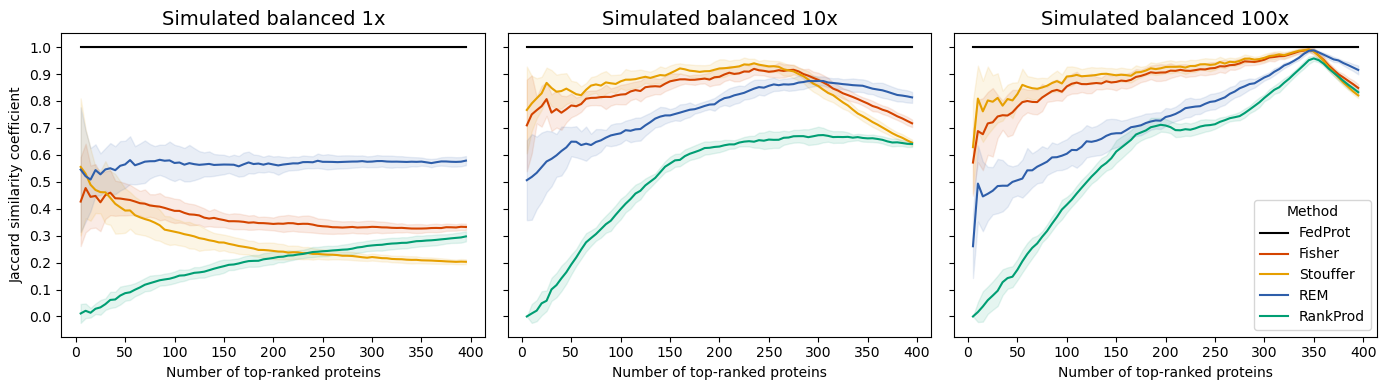

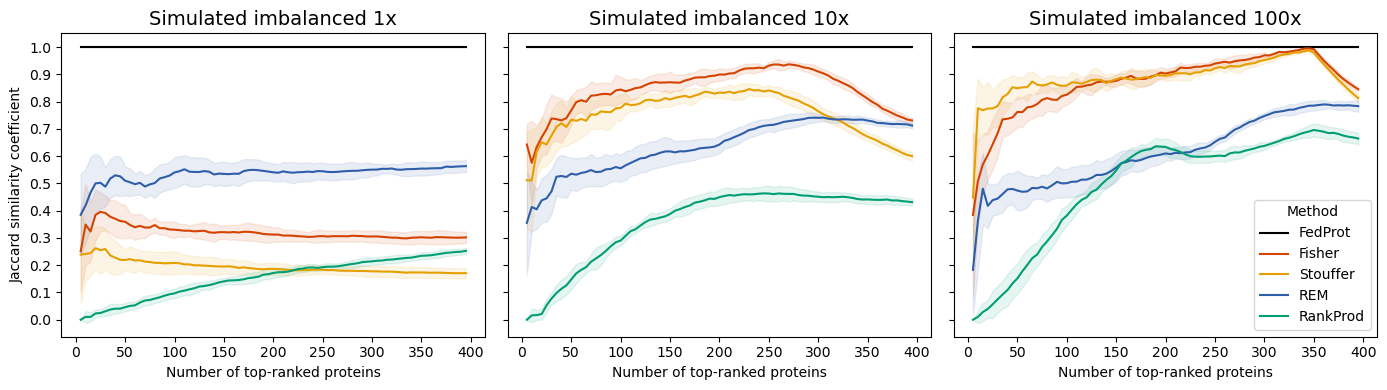

In [11]:
fp_eval.plot_with_confidence(
    {k: jaccard_topN_dfs[k].loc[:,[str(i) for i in range(5,400,5)]] for k in ["Balanced 1x", "Balanced 10x", "Balanced 100x"]},
    ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"], 
    color_dict,
    figsize=(14, 4),
    titles=["Balanced 1x", "Balanced 10x", "Balanced 100x"],
)

fp_eval.plot_with_confidence(
    {k: jaccard_topN_dfs[k].loc[:,[str(i) for i in range(5,400,5)]] for k in ["Imbalanced 1x", "Imbalanced 10x", "Imbalanced 100x"]},
    ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"], 
    color_dict,
    figsize=(14, 4),
    titles=["Imbalanced 1x", "Imbalanced 10x", "Imbalanced 100x"],
)

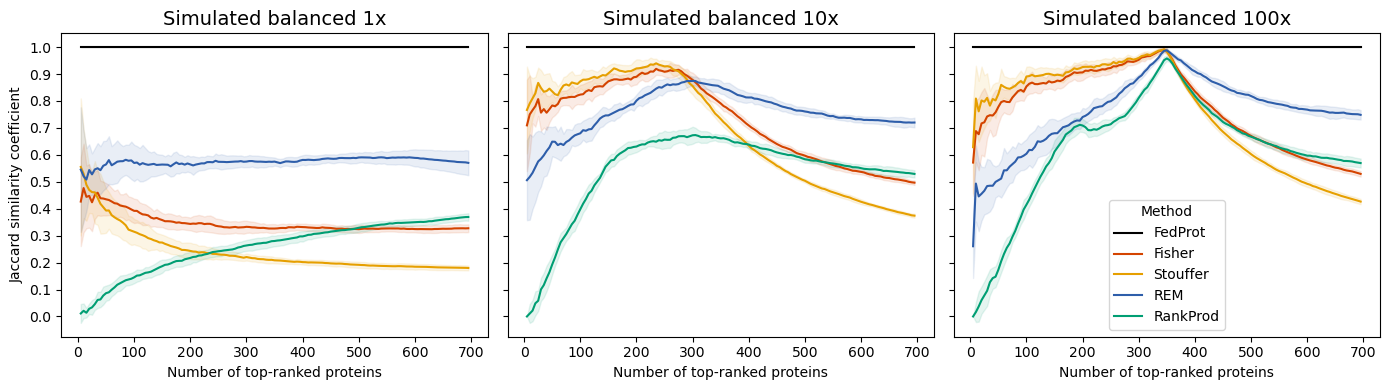

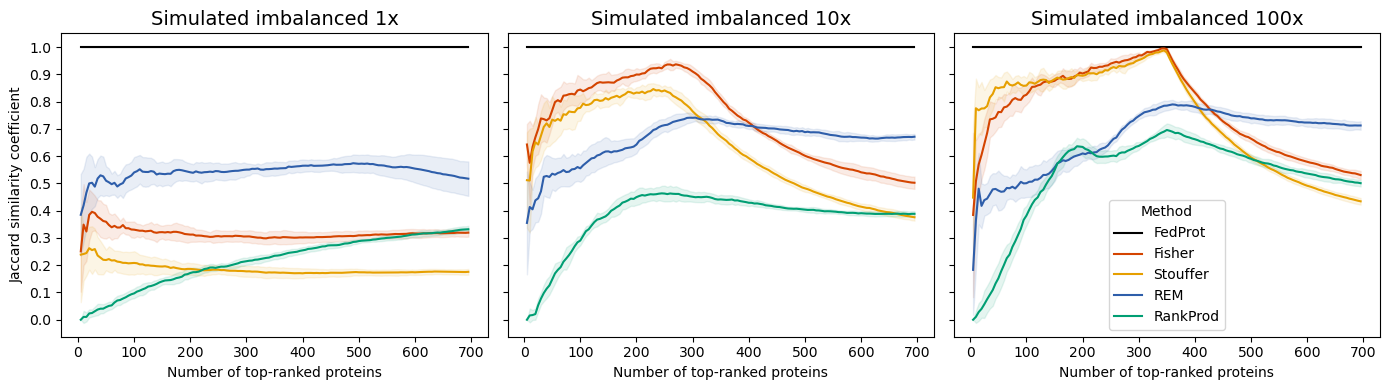

In [12]:
fp_eval.plot_with_confidence(
    {k: jaccard_topN_dfs[k] for k in ["Balanced 1x", "Balanced 10x", "Balanced 100x"]},
    ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"], 
    color_dict,
    figsize=(14, 4),
    titles=["Balanced 1x", "Balanced 10x", "Balanced 100x"],
)

fp_eval.plot_with_confidence(
    {k: jaccard_topN_dfs[k] for k in ["Imbalanced 1x", "Imbalanced 10x", "Imbalanced 100x"]},
    ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"], 
    color_dict,
    figsize=(14, 4),
    titles=["Imbalanced 1x", "Imbalanced 10x", "Imbalanced 100x"],
)